In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv('/content/PCOS_data.csv')

In [ ]:
df

,Sl. No,Patient File No.,PCOS (Y/N),Age,Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.000,19.3,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.500,24.9,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.000,25.3,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.000,29.7,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.000,20.1,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,537,537,0,35,50.0,164.592,18.5,17,72,16,...,0,0.0,0,110,70,1,0,17.5,10.0,6.7
537,538,538,0,30,63.2,158.000,25.3,15,72,18,...,0,0.0,0,110,70,9,7,19.0,18.0,8.2
538,539,539,0,36,54.0,152.000,23.4,13,74,20,...,0,0.0,0,110,80,1,0,18.0,9.0,7.3
539,540,540,0,27,50.0,150.000,22.2,15,74,20,...,1,0.0,0,110,70,7,6,18.0,16.0,11.5


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5258 - loss: 0.7693 - val_accuracy: 0.5698 - val_loss: 0.7424
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6577 - loss: 0.6225 - val_accuracy: 0.6395 - val_loss: 0.6418
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6928 - loss: 0.5675 - val_accuracy: 0.6512 - val_loss: 0.6233
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7576 - loss: 0.4839 - val_accuracy: 0.6744 - val_loss: 0.5700
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7865 - loss: 0.4682 - val_accuracy: 0.6977 - val_loss: 0.5783
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8097 - loss: 0.4157 - val_accuracy: 0.7791 - val_loss: 0.4631
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7848 - loss: 0.4244 - val_accuracy: 0.7674 - val_loss: 0.4364
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8372 - loss: 0.3861 - val_accuracy: 0.7558 - val_loss: 0.4518


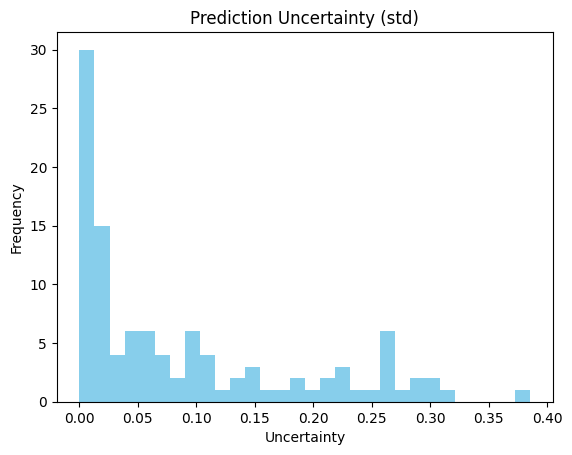

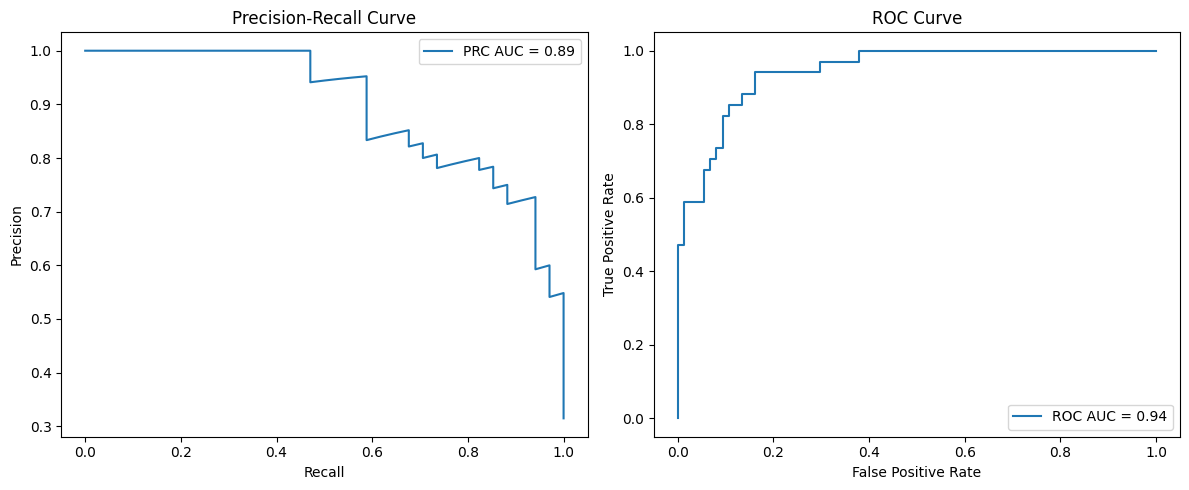

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, precision_recall_curve, auc, roc_curve
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

# Drop irrelevant columns
df = df.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore')

# Drop missing rows
df = df.dropna()

# Separate features and labels
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

# Ensure all feature columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y.loc[X.index]  # Align labels

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Monte Carlo Dropout Layer
class MCDropout(Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

# Bayesian Neural Network
def create_bnn(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        MCDropout(0.5),
        Dense(32, activation='relu'),
        MCDropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

# Compile and train
model = create_bnn(X_train.shape[1])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Prediction with uncertainty
def predict_with_uncertainty(f_model, x, n_iter=50):
    preds = np.array([f_model.predict(x, verbose=0) for _ in range(n_iter)])
    return preds.mean(axis=0), preds.std(axis=0)

mean_pred, std_pred = predict_with_uncertainty(model, X_test)

# Evaluation
y_true = y_test.values  # 🛠️ FIXED missing y_true
y_pred_labels = (mean_pred > 0.5).astype(int)
acc = accuracy_score(y_true, y_pred_labels)
avg_uncertainty = np.mean(std_pred)

print(f"\nAccuracy: {acc * 100:.2f}% ± {avg_uncertainty * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_labels))

# Plot uncertainty histogram
plt.hist(std_pred, bins=30, color='skyblue')
plt.title("Prediction Uncertainty (std)")
plt.xlabel("Uncertainty")
plt.ylabel("Frequency")
plt.show()

# ROC and PRC curves
precision, recall, _ = precision_recall_curve(y_true, mean_pred)
prc_auc = auc(recall, precision)
roc = roc_auc_score(y_true, mean_pred)
fpr, tpr, _ = roc_curve(y_true, mean_pred)

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, label=f'PRC AUC = {prc_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.savefig("roc_prc_curves.png")
plt.show()


Training...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4706 - loss: 0.0899 - val_accuracy: 0.7037 - val_loss: 0.0675
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.5917 - loss: 0.0790 - val_accuracy: 0.7222 - val_loss: 0.0630
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.6661 - loss: 0.0769 - val_accuracy: 0.7407 - val_loss: 0.0629
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.6125 - loss: 0.0684 - val_accuracy: 0.7222 - val_loss: 0.0615
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.6626 - loss: 0.0694 - val_accuracy: 0.7963 - val_loss: 0.0582
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.7145 - loss: 0.0665 - val_accuracy: 0.8519 - val_loss: 0.0527
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.7422 - loss: 0.0628 - val_accuracy: 0.6389 - val_loss: 0.0636
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.7215 - loss: 0.0631 - val_accuracy: 0.8519 - val_loss: 0.0533
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.7716 - loss: 0.0593 - va

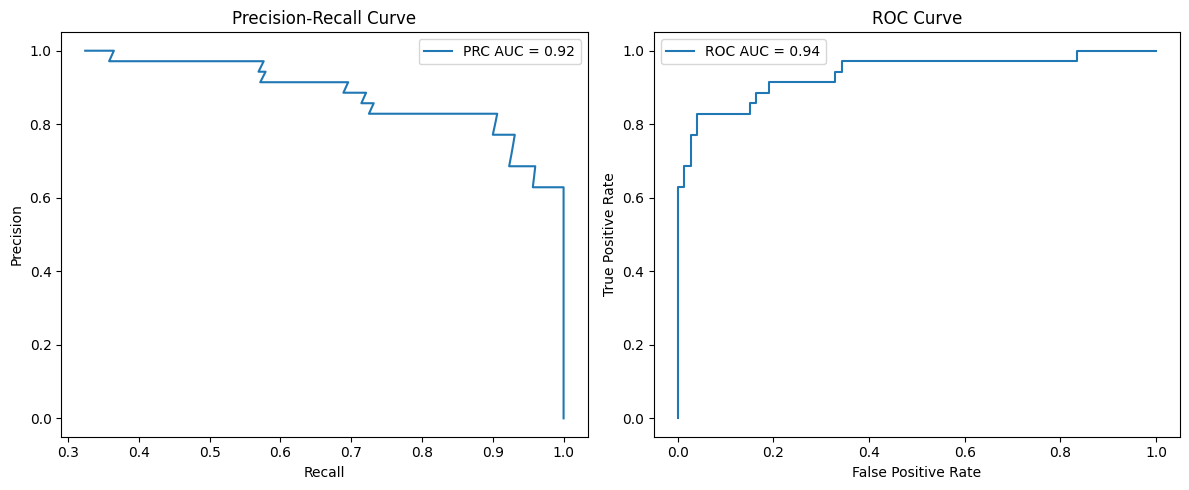

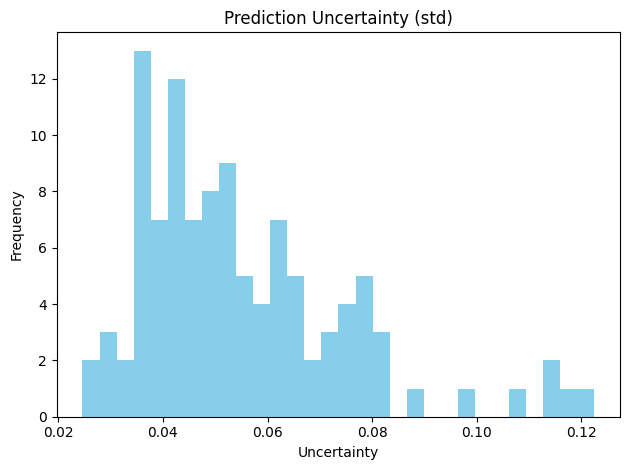

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    accuracy_score, classification_report
)
import matplotlib.pyplot as plt
import joblib

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets.float(), reduction='none')
        pt = torch.exp(-BCE)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE
        return focal_loss.mean()

# Bayesian Linear Layer
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, kl_weight):
        super(BayesianLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.kl_weight = kl_weight
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features).normal_(0, 0.1))
        self.weight_logvar = nn.Parameter(torch.Tensor(out_features, in_features).fill_(-5.0))
        self.bias_mu = nn.Parameter(torch.Tensor(out_features).normal_(0, 0.1))
        self.bias_logvar = nn.Parameter(torch.Tensor(out_features).fill_(-5.0))

    def forward(self, x):
        weight_std = torch.exp(0.5 * self.weight_logvar)
        bias_std = torch.exp(0.5 * self.bias_logvar)
        weight = self.weight_mu + weight_std * torch.randn_like(weight_std)
        bias = self.bias_mu + bias_std * torch.randn_like(bias_std)
        kl = 0.5 * torch.sum(torch.exp(self.weight_logvar) + self.weight_mu**2 - 1.0 - self.weight_logvar)
        kl += 0.5 * torch.sum(torch.exp(self.bias_logvar) + self.bias_mu**2 - 1.0 - self.bias_logvar)
        self.kl = self.kl_weight * kl
        return F.linear(x, weight, bias)

# Bayesian NN
class BayesianNN(nn.Module):
    def __init__(self, input_dim, kl_weight, hidden_units=32, num_layers=2):
        super(BayesianNN, self).__init__()
        self.hidden = nn.ModuleList([
            BayesianLinear(input_dim if i == 0 else hidden_units, hidden_units, kl_weight)
            for i in range(num_layers)
        ])
        self.output = nn.Linear(hidden_units, 1)
        self.bn = nn.ModuleList([nn.BatchNorm1d(hidden_units) for _ in range(num_layers)])
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        kl_total = 0
        for i, layer in enumerate(self.hidden):
            x = F.relu(layer(x))
            kl_total += layer.kl
            x = self.bn[i](x)
            x = self.dropout(x)
        x = self.output(x)
        return x, kl_total

def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs, kl = model(inputs)
        loss = criterion(outputs.squeeze(), targets) + kl
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        predictions = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
        total_correct += (predictions == targets).sum().item()
        total_samples += targets.size(0)
    accuracy = total_correct / total_samples
    return total_loss / len(dataloader), accuracy

def evaluate_model(model, dataloader, device):
    model.eval()
    y_true, y_pred, all_preds = [], [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs_list = []
            for _ in range(10):  # multiple forward passes for uncertainty
                out, _ = model(inputs)
                outputs_list.append(torch.sigmoid(out).cpu().numpy())
            outputs_stack = np.stack(outputs_list, axis=0)
            mean_preds = np.mean(outputs_stack, axis=0).squeeze()
            std_preds = np.std(outputs_stack, axis=0).squeeze()
            y_true.extend(targets.numpy())
            y_pred.extend(mean_preds)
            all_preds.extend(std_preds)
    return np.array(y_true), np.array(y_pred), np.array(all_preds)

def validate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs, kl = model(inputs)
            loss = criterion(outputs.squeeze(), targets) + kl
            total_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).float()
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

def main_pipeline(data_path):
    df = pd.read_csv(data_path)
    df = df.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore').dropna()
    y = df['PCOS (Y/N)']
    X = df.drop(columns=['PCOS (Y/N)']).apply(pd.to_numeric, errors='coerce').dropna()
    y = y.loc[X.index]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

    feature_names = X.columns
    rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
    top_features = pd.Series(rf.feature_importances_, index=feature_names).nlargest(7).index.tolist()
    feature_indices = [list(feature_names).index(f) for f in top_features]
    X_train, X_test = X_train[:, feature_indices], X_test[:, feature_indices]

    X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                            torch.tensor(y_train.values, dtype=torch.float32)), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                           torch.tensor(y_test.values, dtype=torch.float32)), batch_size=64, shuffle=False)

    model = BayesianNN(input_dim=X_train.shape[1], kl_weight=1e-5).to(device)
    criterion = FocalLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    print("Training...")
    for epoch in range(1, 51):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_model(model, test_loader, criterion, device)
        print(f"Epoch {epoch}/50")
        print(f"{len(train_loader)}/{len(train_loader)} ━━━━━━━━━━━━━━━━━━━━ - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")

    y_true, mean_pred, std_pred = evaluate_model(model, test_loader, device)

    y_pred_labels = (mean_pred > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred_labels)
    avg_uncertainty = np.mean(std_pred)
    print(f"\nValidation Accuracy: {acc * 100:.2f}% ± {avg_uncertainty * 100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_true, y_pred_labels))

    # ROC and PRC
    fpr, tpr, _ = precision_recall_curve(y_true, mean_pred)
    roc = roc_auc_score(y_true, mean_pred)
    prc_auc = auc(tpr, fpr)
    print(f"ROC AUC: {roc:.4f}, PRC AUC: {prc_auc:.4f}")

    # Plot PRC and ROC
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'PRC AUC = {prc_auc:.2f}')
    plt.xlabel('Recall'), plt.ylabel('Precision'), plt.title('Precision-Recall Curve')
    plt.legend()

    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, mean_pred)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc:.2f}')
    plt.xlabel('False Positive Rate'), plt.ylabel('True Positive Rate'), plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig("roc_prc_curves.png")
    plt.show()

    # Uncertainty histogram
    plt.hist(std_pred, bins=30, color='skyblue')
    plt.title("Prediction Uncertainty (std)")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("uncertainty_histogram.png")
    plt.show()

    torch.save(model.state_dict(), 'bayesian_pcos_model.pt')
    joblib.dump(scaler, 'scaler.pkl')
    return model, scaler, mean_pred, std_pred

# Entry
if __name__ == "__main__":
    data_path = "/content/PCOS_data.csv"
    model, scaler, mean_pred, std_pred = main_pipeline(data_path)


Training model 1/5
Training model 2/5
Training model 3/5
Training model 4/5
Training model 5/5

Accuracy: 88.89% ± 3.15%

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        74
           1       0.89      0.74      0.81        34

    accuracy                           0.89       108
   macro avg       0.89      0.85      0.86       108
weighted avg       0.89      0.89      0.89       108



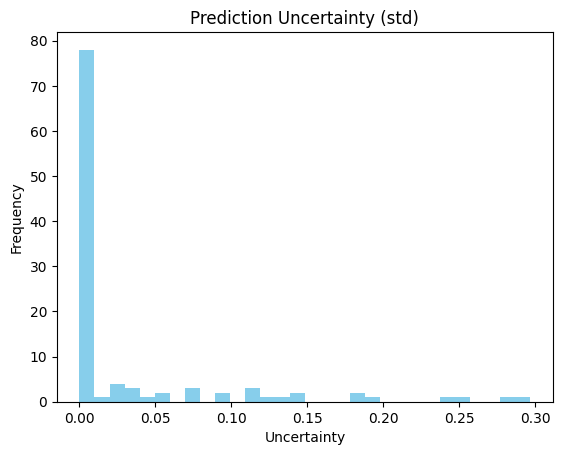

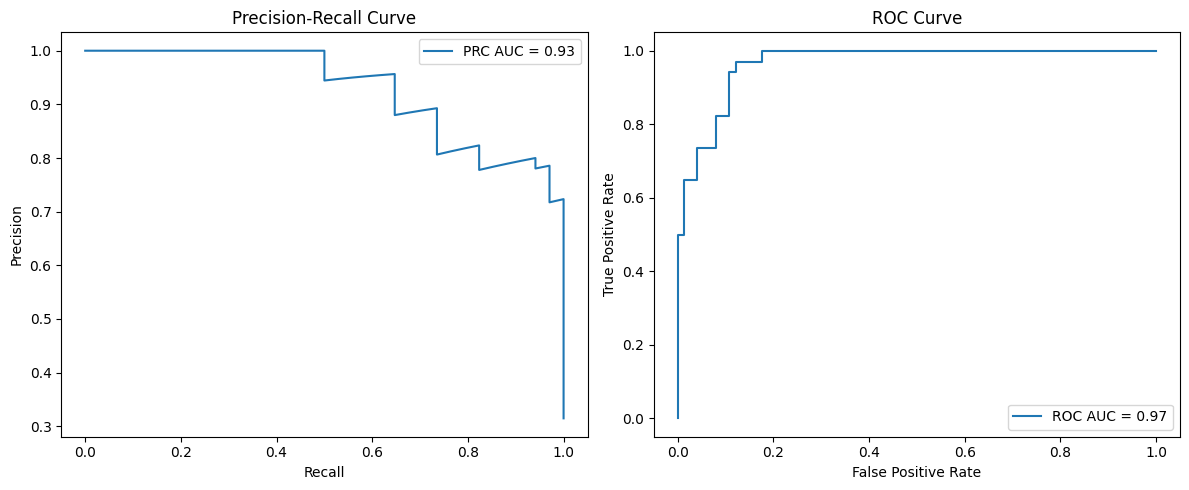

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, classification_report, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

# Set seeds for reproducibility
def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Define the Deterministic Neural Network
class DeterministicNN(nn.Module):
    def __init__(self, input_dim):
        super(DeterministicNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.out(x))
        return x

# Train a single model
def train_single_model(model, X_train, y_train, epochs=30, batch_size=32):
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    model.train()
    for epoch in range(epochs):
        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

# Train ensemble of models
def train_ensemble(X_train, y_train, n_models=5):
    ensemble = []
    input_dim = X_train.shape[1]
    for i in range(n_models):
        print(f"Training model {i+1}/{n_models}")
        model = DeterministicNN(input_dim)
        train_single_model(model, X_train, y_train)
        ensemble.append(model)
    return ensemble

# Predict using ensemble
def ensemble_predict(ensemble, X_test):
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    preds = np.array([model(X_test_tensor).detach().numpy().flatten() for model in ensemble])
    return preds.mean(axis=0), preds.std(axis=0)

# Plot prediction uncertainty
def plot_uncertainty(std_pred):
    plt.hist(std_pred, bins=30, color='skyblue')
    plt.title("Prediction Uncertainty (std)")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
    plt.show()

# Plot ROC and PRC curves
def plot_roc_prc(y_true, y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    prc_auc = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(recall, precision, label=f'PRC AUC = {prc_auc:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    plt.tight_layout()
    plt.savefig("roc_prc_curves.png")
    plt.show()

# Main pipeline
def main_ensemble_pipeline(X_train, y_train, X_test, y_test):
    set_seeds()
    ensemble = train_ensemble(X_train, y_train, n_models=5)
    mean_preds, std_preds = ensemble_predict(ensemble, X_test)
    y_pred_labels = (mean_preds > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred_labels)
    avg_uncertainty = np.mean(std_preds)

    print(f"\nAccuracy: {acc * 100:.2f}% ± {avg_uncertainty * 100:.2f}%")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_labels))

    plot_uncertainty(std_preds)
    plot_roc_prc(y_test, mean_preds)



if __name__ == '__main__':
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    main_ensemble_pipeline(X_train, y_train, X_test, y_test)
